# ISyE 6525 HW2 - Question 4

## Edge detection and segmentation


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import convolve

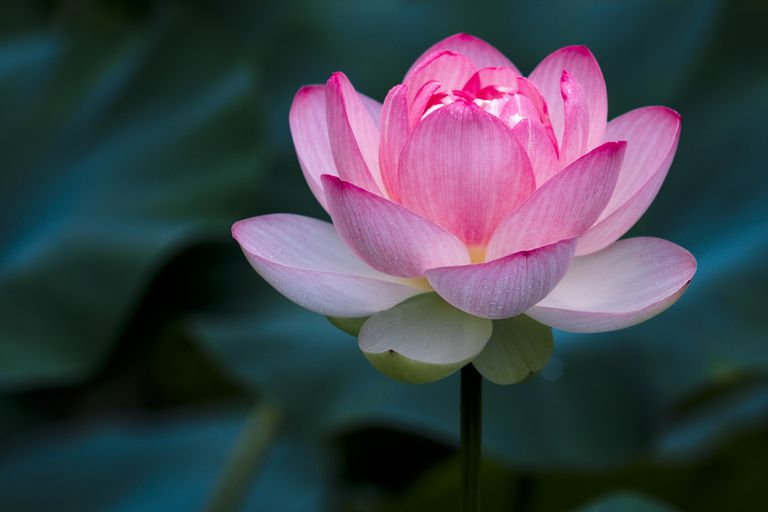

In [5]:
IMAGE_PATH = Path("Flower.jpg")
flower = Image.open(IMAGE_PATH)
display(flower)

## (a) Laplacian of Gaussian (8 pts)

For

$$
G(x,y)=\frac{1}{2\pi\sigma^2}\exp\left(-\frac{x^2+y^2}{2\sigma^2}\right),
$$

compute $\nabla^2G=\frac{\partial^2G}{\partial x^2}+\frac{\partial^2G}{\partial y^2}$ and show the derivation.

### Derivation
For fixed $\sigma>0$, write $G=G(x,y)$. The first derivative is

$$
\frac{\partial G}{\partial x}
=\frac{1}{2\pi\sigma^2}\left(-\frac{2x}{2\sigma^2}\right)\exp\left(-\frac{x^2+y^2}{2\sigma^2}\right)
=-\frac{x}{\sigma^2}G.
$$

Second partial derivative with respect to $x$:
$$
\begin{aligned}
\frac{\partial^2G}{\partial x^2}
&=-\frac{1}{\sigma^2}G-\frac{x}{\sigma^2}\frac{\partial G}{\partial x}\\
&=-\frac{1}{\sigma^2}G+\frac{x^2}{\sigma^4}G\\
&=\frac{x^2-\sigma^2}{\sigma^4}G.
\end{aligned}
$$

By symmetry,

$$
\frac{\partial^2G}{\partial y^2}=\frac{y^2-\sigma^2}{\sigma^4}G.
$$

Adding the two second partial derivatives gives

$$
\boxed{\nabla^2G(x,y)=\frac{x^2+y^2-2\sigma^2}{\sigma^4}G(x,y)
=\frac{x^2+y^2-2\sigma^2}{2\pi\sigma^6}\exp\left(-\frac{x^2+y^2}{2\sigma^2}\right).}
$$

### Construct and apply the Laplacian-of-Gaussian kernel

- Construct a $5\times5$ LoG kernel with $\sigma=1$ on $x,y\in\{-2,-1,0,1,2\}$.
- Report the kernel numerically.
- Explain why the sampled kernel should be shifted so its entries sum to zero.
- Convolve it with the grayscale image and display the result.

Raw LoG kernel:
[[0.00291502 0.01306423 0.02153928 0.01306423 0.00291502]
 [0.01306423 0.05854983 0.09653235 0.05854983 0.01306423]
 [0.02153928 0.09653235 0.15915494 0.09653235 0.02153928]
 [0.01306423 0.05854983 0.09653235 0.05854983 0.01306423]
 [0.00291502 0.01306423 0.02153928 0.01306423 0.00291502]]
Zero-sum LoG kernel:
[[-0.03635757 -0.02620836 -0.01773331 -0.02620836 -0.03635757]
 [-0.02620836  0.01927724  0.05725976  0.01927724 -0.02620836]
 [-0.01773331  0.05725976  0.11988235  0.05725976 -0.01773331]
 [-0.02620836  0.01927724  0.05725976  0.01927724 -0.02620836]
 [-0.03635757 -0.02620836 -0.01773331 -0.02620836 -0.03635757]]


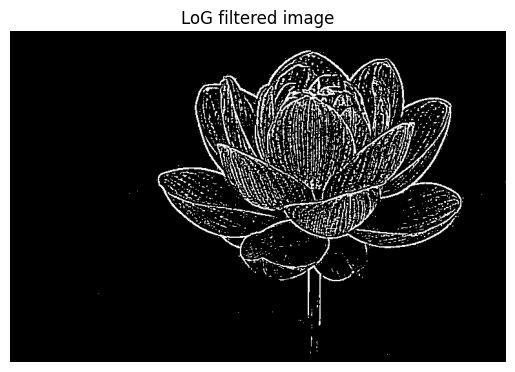

In [12]:
# 5 x 5 LoG kernel. sigma=1
sigma = 1
yy, xx = np.mgrid[-2:3, -2:3]
log_kernel = (1/(2*np.pi*sigma**2)) * np.exp(-(xx**2 + yy**2) / (2*sigma**2))
print(f"Raw LoG kernel:\n{log_kernel}")
# Shift the kernel so its entries sum to zero.
log_kernel -= log_kernel.mean()
print(f"Zero-sum LoG kernel:\n{log_kernel}")
# Convolve it with the grayscale image and display the result.
flower_gray = np.array(flower.convert("L"))
flower_log = convolve(flower_gray, log_kernel, mode="reflect")
plt.imshow(flower_log, cmap="gray")
plt.title("LoG filtered image")
plt.axis("off")
plt.show()

### Zero-sum explanation

TODO

## (b) Sobel and Prewitt edge detection (7 pts)

For both the Sobel and Prewitt operators:

- Compute the first partial derivatives $f_x$ and $f_y$ of the grayscale image.
- Form $|\nabla f|=\sqrt{f_x^2+f_y^2}$.
- Display thresholded edge maps for at least four cutoff values.
- Describe what happens as the cutoff increases.
- State which operator gives the larger response and explain why.

### Sobel operator

In [ ]:
# TODO: Compute Sobel derivatives and gradient magnitude.
# TODO: Display thresholded edge maps at four or more cutoff values.

### Prewitt operator

In [ ]:
# TODO: Compute Prewitt derivatives and gradient magnitude.
# TODO: Display thresholded edge maps at four or more cutoff values.

### Edge-map comparison

<!-- TODO: Discuss increasing cutoffs and compare Sobel with Prewitt. -->

## (c) Colour segmentation with k-means (6 pts)

Segment the colour image into 2, 3, 4, and 5 clusters. Display all four segmented images and report the cluster centres for each value of $k$.

In [ ]:
# TODO: Run k-means for k in {2, 3, 4, 5}.
# TODO: Display the segmented images and report their cluster centres.

## (d) Multilevel Otsu segmentation (4 pts)

Use Otsu's method to segment the grayscale image into 2, 3, 4, and 5 levels. Report the threshold values for every case and display the corresponding quantized images.

In [ ]:
# TODO: Apply multilevel Otsu segmentation for 2, 3, 4, and 5 levels.
# TODO: Report thresholds and display the quantized images.